#### [transformer models]
- 인코더 : Bert
- 인코더-디코더 : BART (요약, 번역에 사용)
- 디코더 : GPT, Gemini, Gemma


hugging face
- model + tokenizer 제공
- tokenizer: 토큰을 나누는 기능 제공 (모델의 임베딩 레이어는 가공되지 않은 텍스트 직접 처리 불가하므로 토크나이저를 이용해 단어 쪼개고 고유 정수 ID로 매핑함)
  - BPE, WordPiece, SentencePiece

# 6장 2강: 허깅페이스 모델 실습
## 2. 트랜스포머 아키텍처별 모델 실습


### 2.2 인코더 모델 활용: KoBERT로 감정 분류

In [ ]:
# 토크나이저 및 모델 로드
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# KoBERT 토크나이저와 모델 로드
tokenizer = AutoTokenizer.from_pretrained("monologg/kobert", trust_remote_code=True)
model = AutoModelForSequenceClassification.from_pretrained("rkdaldus/ko-sent5-classification")

# 사용자 입력 텍스트 감정 분석
text = "오늘 정말 행복해!"
text = "너무 무서워!"
inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True)
with torch.no_grad():
    outputs = model(**inputs)
predicted_label = torch.argmax(outputs.logits, dim=1).item()

# 감정 레이블 정의
emotion_labels = {
    0: ("Angry", "😡"),
    1: ("Fear", "😨"),
    2: ("Happy", "😊"),
    3: ("Tender", "🥰"),
    4: ("Sad", "😢")
}

# 예측된 감정 출력
print(f"예측된 감정: {emotion_labels[predicted_label][0]} {emotion_labels[predicted_label][1]}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: rkdaldus/ko-sent5-classification
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


예측된 감정: Happy 😊


### 2.3 인코더-디코더 모델 활용: KoBART로 뉴스 요약

In [1]:
import torch
from transformers import PreTrainedTokenizerFast
from transformers import BartForConditionalGeneration

tokenizer = PreTrainedTokenizerFast.from_pretrained('gogamza/kobart-summarization')
model = BartForConditionalGeneration.from_pretrained('gogamza/kobart-summarization')

text = "과거를 떠올려보자. 방송을 보던 우리의 모습을. 독보적인 매체는 TV였다. 온 가족이 둘러앉아 TV를 봤다. 간혹 가족들끼리 뉴스와 드라마, 예능 프로그램을 둘러싸고 리모컨 쟁탈전이 벌어지기도  했다. 각자 선호하는 프로그램을 ‘본방’으로 보기 위한 싸움이었다. TV가 한 대인지 두 대인지 여부도 그래서 중요했다. 지금은 어떤가. ‘안방극장’이라는 말은 옛말이 됐다. TV가 없는 집도 많다. 미디어의 혜 택을 누릴 수 있는 방법은 늘어났다. 각자의 방에서 각자의 휴대폰으로, 노트북으로, 태블릿으로 콘텐츠 를 즐긴다."

raw_input_ids = tokenizer.encode(text)
input_ids = [tokenizer.bos_token_id] + raw_input_ids + [tokenizer.eos_token_id]

summary_ids = model.generate(torch.tensor([input_ids]))
tokenizer.decode(summary_ids.squeeze().tolist(), skip_special_tokens=True)


model.safetensors: reconstructing file:   0%|          |  0.00B /  496MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

/Users/myungjilee/Desktop/Kant/ax_study/04_MACHINE_LEARNING/.venv/lib/python3.13/site-packages/transformers/generation/utils.py:1676: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


'TV가 없는 집도 많아지고 미디어의 혜 택을 누릴 수 있는 방법은 늘어났다.'

### 2.4 디코더 모델 활용: Gemma로 대화형 텍스트 생성

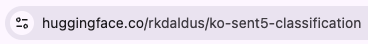
- 식별자: ko-sent5-classification

In [ ]:
from transformers import pipeline
import torch

# 식별자 설정
gemma_identifier = "google/gemma-2b-it"

gemma_generator = pipeline(
    "text-generation",
    model=gemma_identifier,
    dtype=torch.bfloat16, # byte 줄이기 -> 16byte -> 8bytpe 적은 사양에서도 돌아갈 수 있도록 함. 숫자가 작아지기 때문에 예측확률은 떨어질 수 있음
    device_map="auto" # accelerate 설치 가능
    #top_p=0.9,
    #top_k=50,
    #temperature=0.7
)

"""
role:  
     system: 역할, 컨텍스트 ...
     user: 전달할 대화
     assistant: AI가 답변한 내용, 지난 대화 내용 + (user + assistnat)
"""

user_dialogue = [
    {"role": "user", "content": "내 이름은 무엇이지?"}
]

outputs = gemma_generator(user_dialogue, max_new_tokens=150) #150자 이내 답변 설정
outputs


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
under_dialogue = [
    {"role": "user", "content": "내 이름은 김철수야"},
    {"role": "assistant", "content": "반갑습니다. 철수님!"},
    {"role": "user", "content": "내 이름은 무엇이지?"}

]

outputs = gemma_generater(user_dialogue, max_new_tokens=150)
outputs